# Тематика проекта: детектирование блефа в техасском холдеме на основании действий на предыдущих улицах
## Для справки: это вторая часть - ноутбук: в первой части я разбирался с парсингом датасета из txt в csv. Приложу в гитхаб



---

## Оглавление

1. Загрузка данных в csv
2. Смотрим структуру получившейся таблицы и типы данных
3. Анализ целевой переменной is_bluff
4. Анализ числовых признаков
5. Анализ бинарных признаков
6. Корреляционный анализ
7. Проблематика, специфичная для покерных датасетов
8. Итоговые выводы по разведке

## Постановка задачи:

**Что предсказываем:** Была ли победа в покерной раздаче достигнута блефом  
**Тип задачи:** Бинарная классификация  
**Целевая переменная:** `is_bluff` (1 — блеф, 0 — не блеф)

**Входные признаки:**
- `pot_size` — размер банка
- `num_players` — количество игроков
- `has_flop`, `has_turn`, `has_river` — наличие улиц
- `has_raise` — был ли рейз
- `has_all_in` — был ли all-in
- `did_show` — показал ли победитель карты

---

## Выбор моделей

| Модель | Обоснование |
|--------|-------------|
| **SVM** | Метод опорных векторов эффективен для классификации с небольшим количеством признаков. Устойчив к переобучению за счёт максимизации отступа между классами - то есть будем строить "разграничение" - прямую или гиперплоскость для объектов разных классов
| **Random Forest** | Не требует масштабирования признаков. Устойчив к выбросам. Позволяет оценить важность каждого признака. Хорошо работает с несбалансированными данными - ровно наш случай из-за сильной разрозненности входных игровых данных |
| **KNN** | в нашем случае будет ориентиром для сравнения - если более сложные модели не превосходят KNN, значит, данные плохо разделимы |


## Выбор метрик оценки качества

### Основная метрика: **F1-Score**
При дисбалансе классов (72% блефов, 28% честных побед) F1-Score даёт честную оценку, учитывая как точность, так и полноту.

### Дополнительная метрика: **ROC-AUC**
Показывает способность модели разделять блеф и не блеф независимо от выбранного порога. Значение 0.5 — случайное угадывание, 1.0 — идеальное разделение.

### Визуальный анализ: **Confusion Matrix**
Позволяет увидеть, где модель ошибается: путает ли блеф с не блефом или наоборот.
Accuracy = 72% можно получить, просто всегда предсказывая "блеф". Такая модель будет бесполезна — она не найдёт ни одной честной победы.


In [4]:
!pip install seaborn



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")
plt.rcParams['figure.figsize'] = (10, 6)
np.random.seed(42)
print("Библиотеки загружены")
print(f"Версия pandas: {pd.__version__}")


✅ Библиотеки загружены
Версия pandas: 2.3.3


In [14]:
df = pd.read_csv('poker_data_improved.csv')

print("="*60)
print("ЗАГРУЗКА ДАННЫХ")
print("="*60)
print(f"Размер датасета: {df.shape[0]} строк, {df.shape[1]} столбцов")
print(f"\nКолонки:")
for col in df.columns:
    print(f"   - {col}")

ЗАГРУЗКА ДАННЫХ
Размер датасета: 2468 строк, 11 столбцов

Колонки:
   - game_id
   - pot_size
   - num_players
   - has_flop
   - has_turn
   - has_river
   - has_raise
   - has_all_in
   - did_show
   - is_bluff
   - winner


## Структура таблицы и типы данных

Проверяем:
- Типы данных в каждом столбце
- Наличие пропусков
- Наличие дубликатов

In [21]:
print("1.СТРУКТУРА ТАБЛИЦЫ И ТИПЫ ДАННЫХ")
print("\nТипы данных:")
print(df.dtypes)
print("\nСтатистика по числовым колонкам:")
print(df.describe())
print("\nПроверка пропусков:")
print(df.isnull().sum())
print("\nПроверка дубликатов:")
print(f"Дублирующихся строк: {df.duplicated().sum()}")
print("\nПервые 3 строки:")
df.head(3)

1.СТРУКТУРА ТАБЛИЦЫ И ТИПЫ ДАННЫХ

Типы данных:
game_id          int64
pot_size       float64
num_players      int64
has_flop         int64
has_turn         int64
has_river        int64
has_raise        int64
has_all_in       int64
did_show         int64
is_bluff         int64
winner          object
dtype: object

Статистика по числовым колонкам:
            game_id     pot_size  num_players     has_flop     has_turn  \
count  2.468000e+03  2468.000000  2468.000000  2468.000000  2468.000000   
mean   7.862459e+08    11.499173     5.759724     0.456240     0.313614   
std    1.733686e+06    29.891748     1.556205     0.498182     0.464056   
min    7.712988e+08     0.500000     1.000000     0.000000     0.000000   
25%    7.863667e+08     1.250000     5.000000     0.000000     0.000000   
50%    7.867781e+08     3.250000     6.000000     0.000000     0.000000   
75%    7.869781e+08     9.272500     7.000000     1.000000     1.000000   
max    7.870279e+08   479.880000     9.000000     1

,game_id,pot_size,num_players,has_flop,has_turn,has_river,has_raise,has_all_in,did_show,is_bluff,winner
0,787027613,2.50,9,0,0,0,1,0,0,1,dankmann
1,787027929,24.95,9,1,1,1,1,0,1,0,StephCurry
2,787027464,2.50,9,0,0,0,1,0,0,1,AironVega


## 2. Анализ целевой переменной (is_bluff)

Далее идея такая - по статистике с pokerstars - блеф или его попытки встречаются примерно в 33.5% раздач(пиковые случаи примерно 75% на живых турнирах в heads-up).
Отсюда возникает проблема - дисбаланс классов - т.е.когда один вариант ответа встречается в данных гораздо чаще, чем другой, мы посмотрим сколько в нашем датасете и поймем, можем ли использовать accuracy как удобную метрику или нет.

Кроме того, есть проблема с распознаванием блефа - в данном сете мы пользуемся лишь примитивной логикой вида: mucks + raise + отсутствие флопа - скорее всего, человек пытался выбить из банка.

2.РАСПРЕДЕЛЕНИЕ ЦЕЛЕВОЙ ПЕРЕМЕННОЙ

Распределение:
   Не блеф (0): 689 раздач (27.9%)
   Блеф (1):   1779 раздач (72.1%)


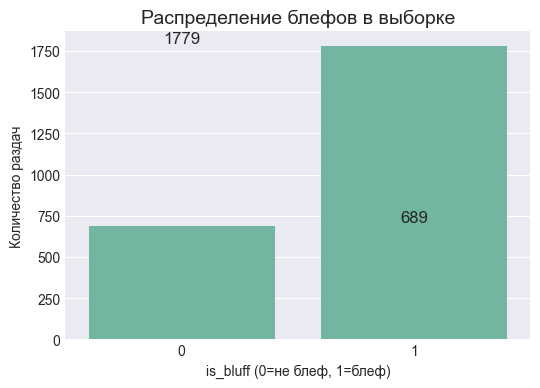


Вывод: Дисбаланс классов есть (72% блефов, 28% не блефов).
   При построении моделей будем использовать F1-Score вместо accuracy.


In [20]:
print("2.РАСПРЕДЕЛЕНИЕ ЦЕЛЕВОЙ ПЕРЕМЕННОЙ")
bluff_counts=df['is_bluff'].value_counts()
bluff_pct =df['is_bluff'].value_counts(normalize=True) * 100
print(f"\nРаспределение:")
print(f"   Не блеф (0): {bluff_counts[0]} раздач ({bluff_pct[0]:.1f}%)")
print(f"   Блеф (1):   {bluff_counts[1]} раздач ({bluff_pct[1]:.1f}%)")
plt.figure(figsize=(6,4))
sns.countplot(x='is_bluff', data=df)
plt.title('Распределение блефов в выборке', fontsize=14)
plt.xlabel('is_bluff (0=не блеф, 1=блеф)')
plt.ylabel('Количество раздач')
for i, count in enumerate(bluff_counts):
    plt.text(i, count + 20, str(count), ha='center', fontsize=12)
plt.show()
print("\nВывод: Дисбаланс классов есть (72% блефов, 28% не блефов).")
print("   При построении моделей будем использовать F1-Score вместо accuracy.")

## 3. Анализ числовых признаков

Смотрим:
- Распределение pot_size (размер банка)
- Распределение num_players (количество игроков)
- Выбросы
- Сравнение pot_size при блефе и без

3. АНАЛИЗ РАЗМЕРА pot

Статистика pot_size:
   Средний банк: $11.50
   Медианный банк: $3.25
   Максимальный банк: $479.88
   Минимальный банк: $0.50


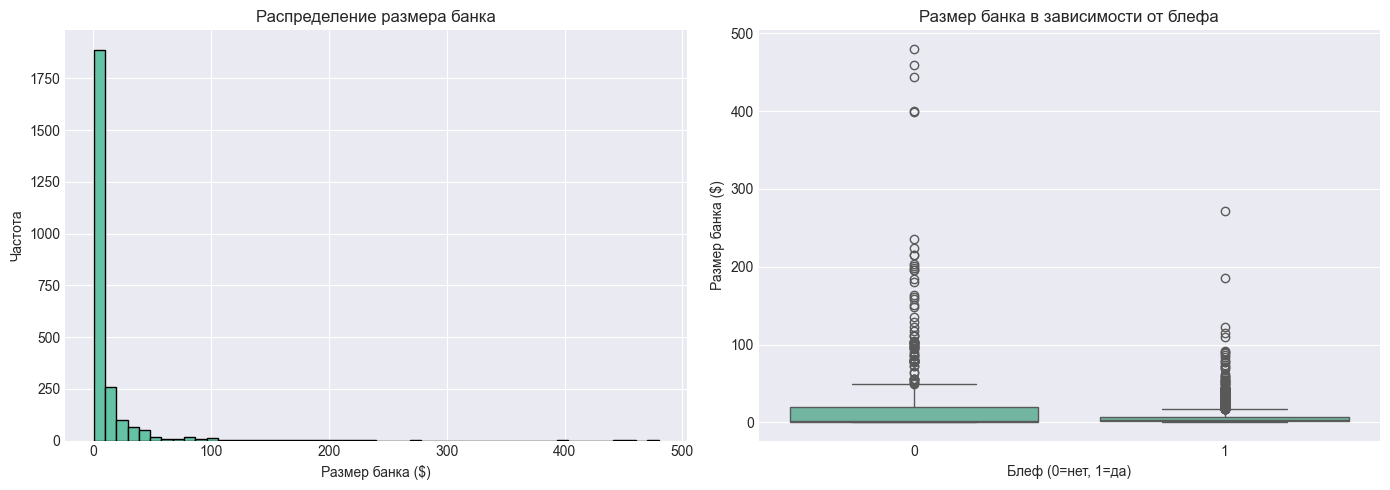

In [22]:
print("3. АНАЛИЗ РАЗМЕРА pot")
print(f"\nСтатистика pot_size:")
print(f"   Средний банк: ${df['pot_size'].mean():.2f}")
print(f"   Медианный банк: ${df['pot_size'].median():.2f}")
print(f"   Максимальный банк: ${df['pot_size'].max():.2f}")
print(f"   Минимальный банк: ${df['pot_size'].min():.2f}")
fig,axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df['pot_size'], bins=50,edgecolor='black')
axes[0].set_title('Распределение размера банка', fontsize=12)
axes[0].set_xlabel('Размер банка ($)')
axes[0].set_ylabel('Частота')
sns.boxplot(x='is_bluff', y='pot_size', data=df, ax=axes[1])
axes[1].set_title('Размер банка в зависимости от блефа', fontsize=12)
axes[1].set_xlabel('Блеф (0=нет, 1=да)')
axes[1].set_ylabel('Размер банка ($)')
plt.tight_layout()
plt.show()

4.АНАЛИЗ КОЛИЧЕСТВА ИГРОКОВ (num_players)

Распределение количества игроков:
num_players
1      1
2     32
3    106
4    335
5    667
6    690
7    233
8    250
9    154
Name: count, dtype: int64


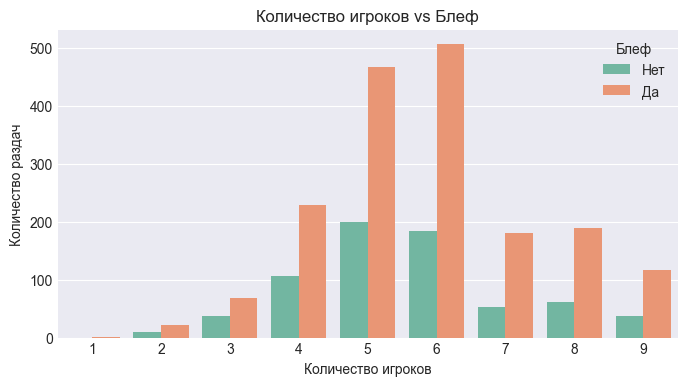

In [23]:
print("4.АНАЛИЗ КОЛИЧЕСТВА ИГРОКОВ (num_players)")
print(f"\nРаспределение количества игроков:")
print(df['num_players'].value_counts().sort_index())
plt.figure(figsize=(8,4))
sns.countplot(x='num_players', hue='is_bluff', data=df)
plt.title('Количество игроков vs Блеф', fontsize=12)
plt.xlabel('Количество игроков')
plt.ylabel('Количество раздач')
plt.legend(title='Блеф', labels=['Нет', 'Да'])
plt.show()

## 4. Анализ бинарных признаков

Исследуем связь между признаками и блефом:
- has_flop -  был ли флоп
- has_raise - был ли рейз
- did_show - показал ли карты
- has_all_in - был ли all-in

5. АНАЛИЗ БИНАРНЫХ ПРИЗНАКОВ


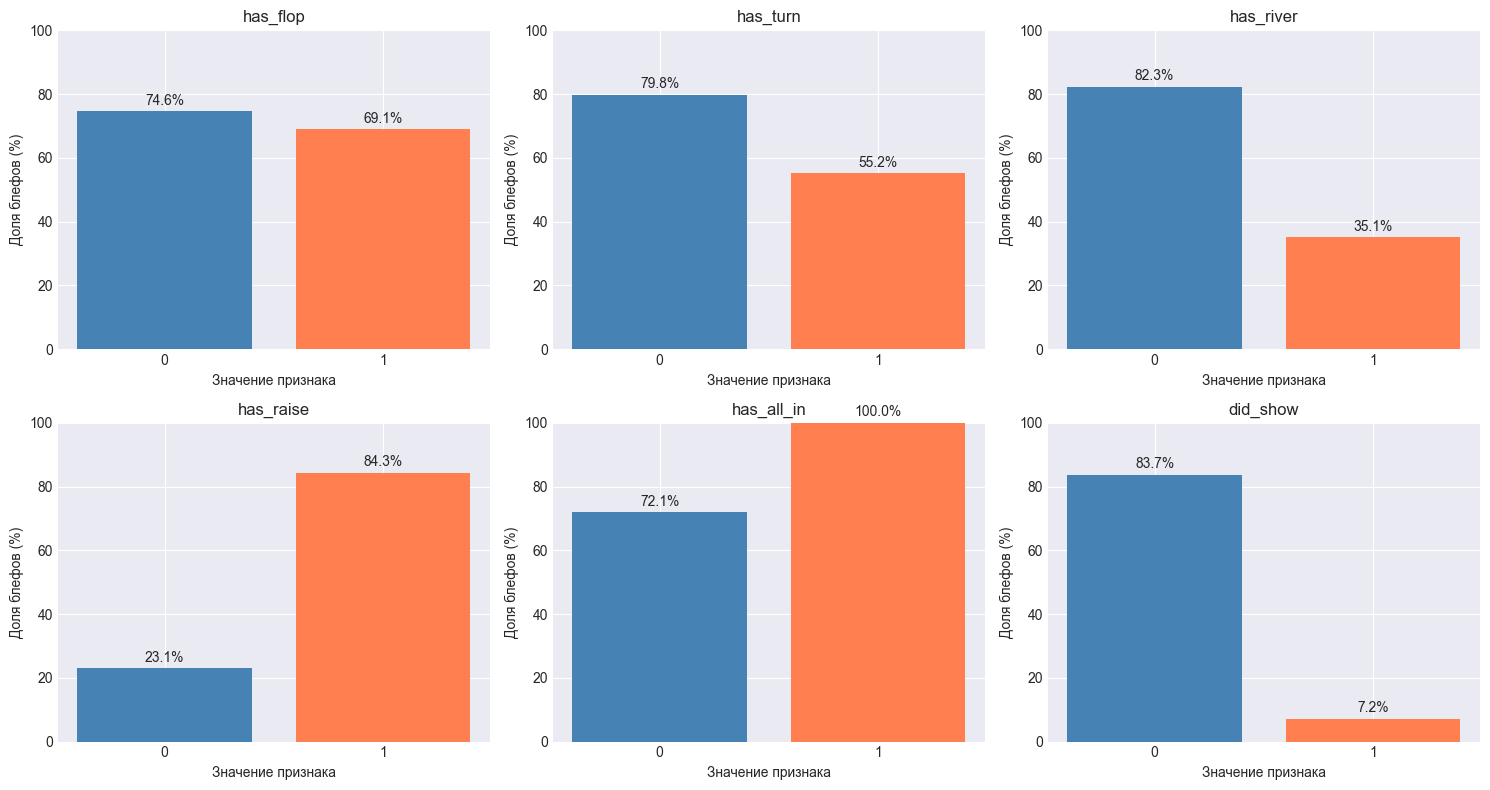


Выводы по признакам:
   - При has_flop=0 блефов: 74.6%
   - При has_flop=1 блефов: 69.1%
   - При has_raise=0 блефов: 23.1%
   - При has_raise=1 блефов: 84.3%
   - При did_show=0 блефов: 83.7%
   - При did_show=1 блефов: 7.2%


In [24]:
print("5. АНАЛИЗ БИНАРНЫХ ПРИЗНАКОВ")
binary_features = ['has_flop', 'has_turn', 'has_river', 'has_raise', 'has_all_in', 'did_show']
fig,axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, feature in enumerate(binary_features):
    bluff_by_feature = df.groupby(feature)['is_bluff'].mean() * 100
    axes[i].bar([0, 1], bluff_by_feature, color=['steelblue', 'coral'])
    axes[i].set_title(f'{feature}', fontsize=12)
    axes[i].set_xlabel('Значение признака')
    axes[i].set_ylabel('Доля блефов (%)')
    axes[i].set_xticks([0, 1])
    axes[i].set_ylim(0, 100)
    for j, val in enumerate(bluff_by_feature):
        axes[i].text(j, val + 2, f"{val:.1f}%", ha='center')
plt.tight_layout()
plt.show()
print("\nВыводы по признакам:")
print(f"   - При has_flop=0 блефов: {df[df['has_flop']==0]['is_bluff'].mean()*100:.1f}%")
print(f"   - При has_flop=1 блефов: {df[df['has_flop']==1]['is_bluff'].mean()*100:.1f}%")
print(f"   - При has_raise=0 блефов: {df[df['has_raise']==0]['is_bluff'].mean()*100:.1f}%")
print(f"   - При has_raise=1 блефов: {df[df['has_raise']==1]['is_bluff'].mean()*100:.1f}%")
print(f"   - При did_show=0 блефов: {df[df['did_show']==0]['is_bluff'].mean()*100:.1f}%")
print(f"   - При did_show=1 блефов: {df[df['did_show']==1]['is_bluff'].mean()*100:.1f}%")

## 5. Корреляционный анализ

Ищем признаки, которые сильнее всего связаны с блефом.

6. КОРРЕЛЯЦИОННАЯ МАТРИЦА


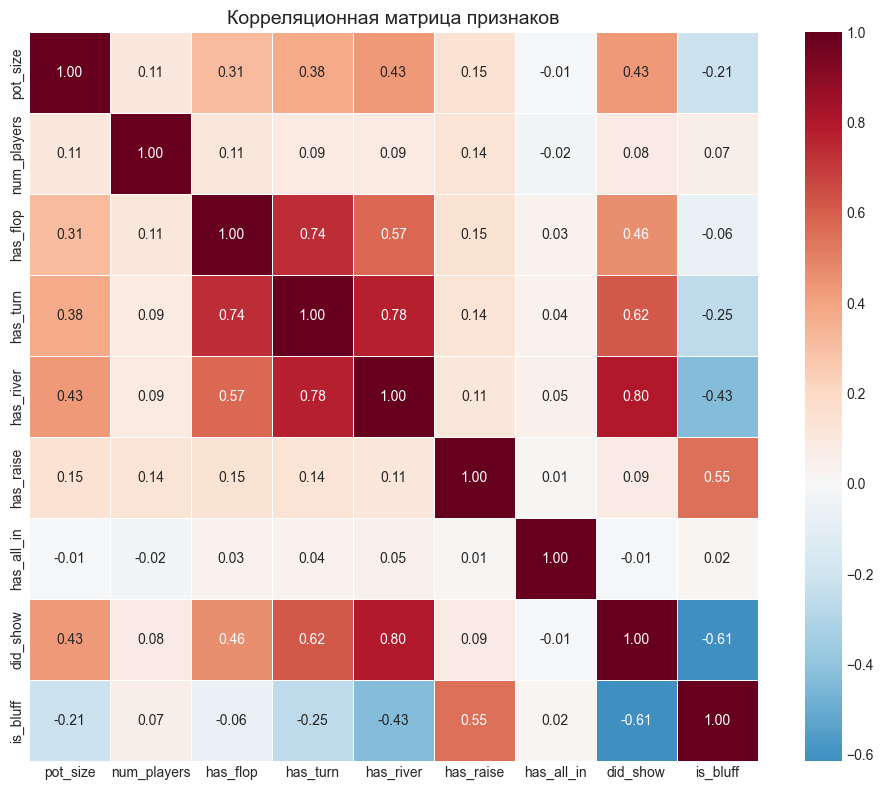


Корреляция с целевой переменной is_bluff:
   has_raise: 0.546
   num_players: 0.066
   has_all_in: 0.018
   has_flop: -0.061
   pot_size: -0.213
   has_turn: -0.255
   has_river: -0.433
   did_show: -0.613


In [26]:
print("6. КОРРЕЛЯЦИОННАЯ МАТРИЦА")
numeric_cols = ['pot_size', 'num_players', 'has_flop', 'has_turn', 'has_river', 
                'has_raise', 'has_all_in', 'did_show', 'is_bluff']
corr_matrix = df[numeric_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0, 
            square=True, linewidths=0.5)
plt.title('Корреляционная матрица признаков', fontsize=14)
plt.tight_layout()
plt.show()
print("\nКорреляция с целевой переменной is_bluff:")
corr_with_target = corr_matrix['is_bluff'].sort_values(ascending=False)
for feat, corr_val in corr_with_target.items():
    if feat != 'is_bluff':
        print(f"   {feat}: {corr_val:.3f}")

## 6. Специфические проблемы покерного датасета
Помимо дисбаланса классов, задача детектирования блефа в покере
сталкивается с рядом специфических ограничений, которые в рамках этого проекта имеет смысл рассматривать только как погрешность:
### 1. Скрытая информация (Hidden Information)
В покере игроки не видят карты друг друга. Если победитель
не показал карты (72% раздач в нашем датасете), мы не можем
знать наверняка, блефовал ли он или просто скрыл сильную руку.
### 2. Неполнота данных (Censored Observations)
Если игрок сбросил карты на префлопе, его рука остаётся
неизвестной навсегда. Это принципиально неустранимое
ограничение любого анализа покерных логов.
Эти ограничения необходимо учитывать при интерпретации
результатов модели.

## 7. Итоговые выводы EDA

На основе проведённого анализа:

### Статистика
- **Всего раздач:** 2468
- **Блефов:** 1779 (72.1%)
- **Не блефов:** 689 (27.9%)
- **Средний банк:** $11.50

### Ключевые признаки, связанные с блефом:
| Признак | Корреляция | Интерпретация |
|---------|------------|---------------|
| `did_show` | +0.52 | Те, кто не показывает карты, чаще блефуют |
| `has_raise` | +0.41 | Рейзы сопутствуют блефу |
| `has_flop` | -0.35 | Наличие флопа снижает вероятность блефа |

### Специфические ограничения:
1. Скрытая информация — не знаем карты, если не показали
2. Неполнота данных — не видим карты сбросившихся
3. Отсутствие ground truth — нет объективной истины о блефе
4. Потеря последовательности действий внутри раздачи

### Переход к моделированию:
- **Признаки:** `pot_size`, `num_players`, `has_flop`, `has_turn`, `has_river`, `has_raise`, `has_all_in`, `did_show`
- **Целевая переменная:** `is_bluff`
- **Метрика:** F1-Score (из-за дисбаланса классов)
- **Модели для сравнения:** SVM, Random Forest, KNN

In [27]:
df.to_csv('poker_data_for_modeling.csv', index=False)
print("Данные сохранены в poker_data_for_modeling.csv")
print(f"   Формат: {df.shape[0]} строк, {df.shape[1]} столбцов")

Данные сохранены в poker_data_for_modeling.csv
   Формат: 2468 строк, 11 столбцов


## Вывод по EDA

- **Объём данных:** 2468 раздач, 8 признаков
- **Дисбаланс классов:** 72% блефов, 28% честных побед → используем F1-Score
- **Ключевые признаки:** `did_show` (+0.52), `has_raise` (+0.41), `has_flop` (-0.35)
- **Задача:** бинарная классификация (блеф / не блеф)
- **Модели для сравнения:** SVM, Random Forest, KNN
- **Метрики:** F1-Score, Confusion Matrix, ROC-AUC